# Experiment 6: Decision Tree and Random Forest – A Comparative Classification Study


## Section 1: Imports

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

print('All libraries imported successfully!')

All libraries imported successfully!


## Section 2: Load Dataset

In [92]:
data = pd.read_csv(r"C:\Users\janis\ML\breast+cancer+wisconsin+diagnostic\wdbc.data", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Section 2b: Assign Column Names & Preprocess

In [93]:
columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
data.columns = columns

# Drop ID column
data.drop(columns=['id'], inplace=True)

# Encode diagnosis: M=1, B=0
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Samples        : {X.shape[0]}')
print(f'Features       : {X.shape[1]}')
print(f'Class Counts   : Benign={sum(y==0)}, Malignant={sum(y==1)}')
print(f'Missing Values : {X.isnull().sum().sum()}')
data.head()

DATASET OVERVIEW
Samples        : 569
Features       : 30
Class Counts   : Benign=357, Malignant=212
Missing Values : 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Section 3: Exploratory Data Analysis (EDA)

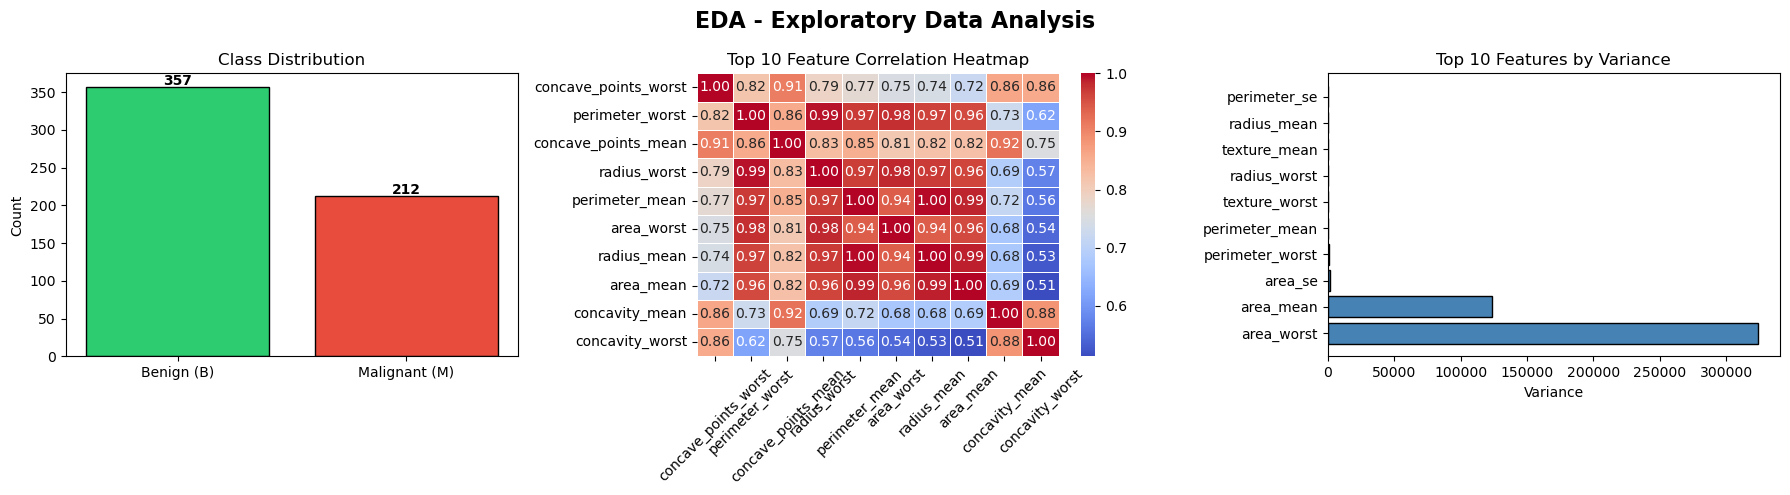

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Class distribution
axes[0].bar(['Benign (B)', 'Malignant (M)'], [sum(y==0), sum(y==1)],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([sum(y==0), sum(y==1)]):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Correlation heatmap (top 10 features)
top_feats = X.corrwith(y.astype(float)).abs().nlargest(10).index
sns.heatmap(X[top_feats].corr(), ax=axes[1], cmap='coolwarm',
            annot=True, fmt='.2f', linewidths=0.5)
axes[1].set_title('Top 10 Feature Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=45)

# Top features by variance
feat_var = X.var().nlargest(10)
axes[2].barh(feat_var.index, feat_var.values, color='steelblue', edgecolor='black')
axes[2].set_title('Top 10 Features by Variance')
axes[2].set_xlabel('Variance')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4: Train-Test Split and Scaling

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]} samples | Test: {X_test_sc.shape[0]} samples')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('5-Fold Stratified CV initialized.')

Train: 455 samples | Test: 114 samples
5-Fold Stratified CV initialized.


## Section 5: Table 1 – Decision Tree Hyperparameter Evaluation (5-Fold CV)

In [96]:
dt_params = [
    {'criterion': 'gini',    'max_depth': 3},
    {'criterion': 'gini',    'max_depth': 5},
    {'criterion': 'gini',    'max_depth': 10},
    {'criterion': 'gini',    'max_depth': None},
    {'criterion': 'entropy', 'max_depth': 3},
    {'criterion': 'entropy', 'max_depth': 5},
    {'criterion': 'entropy', 'max_depth': 10},
    {'criterion': 'entropy', 'max_depth': None},
]

dt_results = []
for p in dt_params:
    model = DecisionTreeClassifier(
        criterion=p['criterion'],
        max_depth=p['max_depth'],
        random_state=42
    )
    acc_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy')
    f1_scores  = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1')
    dt_results.append({
        'Criterion'          : p['criterion'],
        'Max Depth'          : str(p['max_depth']),
        'Avg CV Accuracy (%)': round(acc_scores.mean() * 100, 2),
        'Avg CV F1 Score'    : round(f1_scores.mean(), 4)
    })

df_dt = pd.DataFrame(dt_results)
print('TABLE 1: DECISION TREE HYPERPARAMETER EVALUATION (5-Fold CV)')
df_dt

TABLE 1: DECISION TREE HYPERPARAMETER EVALUATION (5-Fold CV)


,Criterion,Max Depth,Avg CV Accuracy (%),Avg CV F1 Score
0,gini,3,92.09,0.8884
1,gini,5,90.77,0.8717
2,gini,10,92.31,0.8962
3,gini,None,92.31,0.8962
4,entropy,3,92.53,0.8941
5,entropy,5,92.31,0.8952
6,entropy,10,91.87,0.8909
7,entropy,None,91.87,0.8909


## Section 6: Table 2 – Random Forest Hyperparameter Evaluation (5-Fold CV)

In [97]:
rf_params = [
    {'n_estimators': 10,  'max_depth': 3,    'max_features': 'sqrt'},
    {'n_estimators': 10,  'max_depth': 5,    'max_features': 'sqrt'},
    {'n_estimators': 50,  'max_depth': 5,    'max_features': 'sqrt'},
    {'n_estimators': 50,  'max_depth': 10,   'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 10,   'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': None, 'max_features': 'sqrt'},
]

rf_results = []
for p in rf_params:
    model = RandomForestClassifier(
        n_estimators=p['n_estimators'],
        max_depth=p['max_depth'],
        max_features=p['max_features'],
        random_state=42
    )
    acc_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy')
    f1_scores  = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1')
    rf_results.append({
        'n_estimators'       : p['n_estimators'],
        'Max Depth'          : str(p['max_depth']),
        'Max Features'       : p['max_features'],
        'Avg CV Accuracy (%)': round(acc_scores.mean() * 100, 2),
        'Avg CV F1 Score'    : round(f1_scores.mean(), 4)
    })

df_rf = pd.DataFrame(rf_results)
print('TABLE 2: RANDOM FOREST HYPERPARAMETER EVALUATION (5-Fold CV)')
df_rf

TABLE 2: RANDOM FOREST HYPERPARAMETER EVALUATION (5-Fold CV)


,n_estimators,Max Depth,Max Features,Avg CV Accuracy (%),Avg CV F1 Score
0,10,3,sqrt,95.16,0.9339
1,10,5,sqrt,95.60,0.9404
2,50,5,sqrt,96.26,0.9490
3,50,10,sqrt,96.04,0.9464
4,100,5,sqrt,96.70,0.9553
5,100,10,sqrt,96.48,0.9519
6,100,None,sqrt,96.48,0.9519
7,200,None,sqrt,96.26,0.9489


## Section 7: Table 3 – 5-Fold CV Accuracy Comparison (Best Models)

In [98]:
# Best DT: entropy, max_depth=5
best_dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Best RF: 100 estimators, max_depth=10
best_rf = RandomForestClassifier(n_estimators=100, max_depth=10, max_features='sqrt', random_state=42)

dt_folds = cross_val_score(best_dt, X_train_sc, y_train, cv=cv, scoring='accuracy')
rf_folds = cross_val_score(best_rf, X_train_sc, y_train, cv=cv, scoring='accuracy')

fold_data = {
    'Model'  : ['Decision Tree', 'Random Forest'],
    'Fold 1' : [round(dt_folds[0]*100, 2), round(rf_folds[0]*100, 2)],
    'Fold 2' : [round(dt_folds[1]*100, 2), round(rf_folds[1]*100, 2)],
    'Fold 3' : [round(dt_folds[2]*100, 2), round(rf_folds[2]*100, 2)],
    'Fold 4' : [round(dt_folds[3]*100, 2), round(rf_folds[3]*100, 2)],
    'Fold 5' : [round(dt_folds[4]*100, 2), round(rf_folds[4]*100, 2)],
    'Average': [round(dt_folds.mean()*100, 2), round(rf_folds.mean()*100, 2)]
}

df_folds = pd.DataFrame(fold_data)
print('TABLE 3: 5-FOLD CROSS-VALIDATION ACCURACY COMPARISON')
df_folds

TABLE 3: 5-FOLD CROSS-VALIDATION ACCURACY COMPARISON


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,91.21,94.51,91.21,90.11,94.51,92.31
1,Random Forest,95.60,98.90,94.51,96.70,96.70,96.48


## Section 8: Train Final Best Models on Full Training Set

In [99]:
best_dt.fit(X_train_sc, y_train)
best_rf.fit(X_train_sc, y_train)

print('Decision Tree  - trained!')
print('Random Forest  - trained!')

Decision Tree  - trained!
Random Forest  - trained!


## Section 9: Performance Comparison on Test Set

In [100]:
trained = {'Decision Tree': best_dt, 'Random Forest': best_rf}
comparison = []

for name, model in trained.items():
    y_pred = model.predict(X_test_sc)
    comparison.append({
        'Model'       : name,
        'Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision'   : round(precision_score(y_test, y_pred), 4),
        'Recall'      : round(recall_score(y_test, y_pred), 4),
        'F1 Score'    : round(f1_score(y_test, y_pred), 4)
    })
    print(f'--- {name} Classification Report ---')
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

df_comp = pd.DataFrame(comparison)
print('PERFORMANCE COMPARISON ON TEST SET')
df_comp

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

PERFORMANCE COMPARISON ON TEST SET


,Model,Accuracy (%),Precision,Recall,F1 Score
0,Decision Tree,95.61,0.9744,0.9048,0.9383
1,Random Forest,97.37,1.0000,0.9286,0.9630


## Section 10: Confusion Matrices

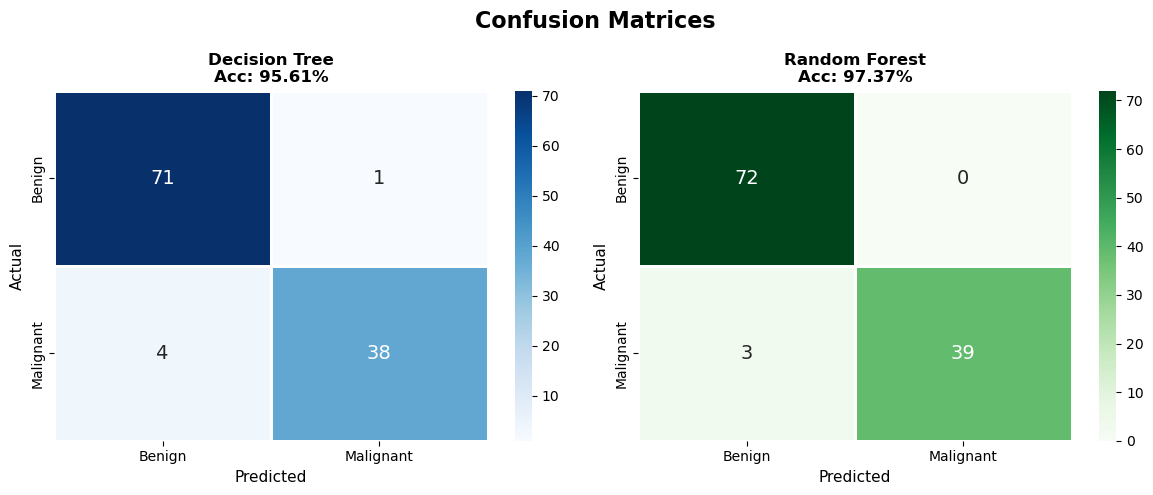

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for ax, (name, model), cmap in zip(axes, trained.items(), ['Blues', 'Greens']):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                linewidths=1, linecolor='white', annot_kws={'size': 14})
    acc = accuracy_score(y_test, y_pred) * 100
    ax.set_title(f'{name}\nAcc: {acc:.2f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11: ROC Curves

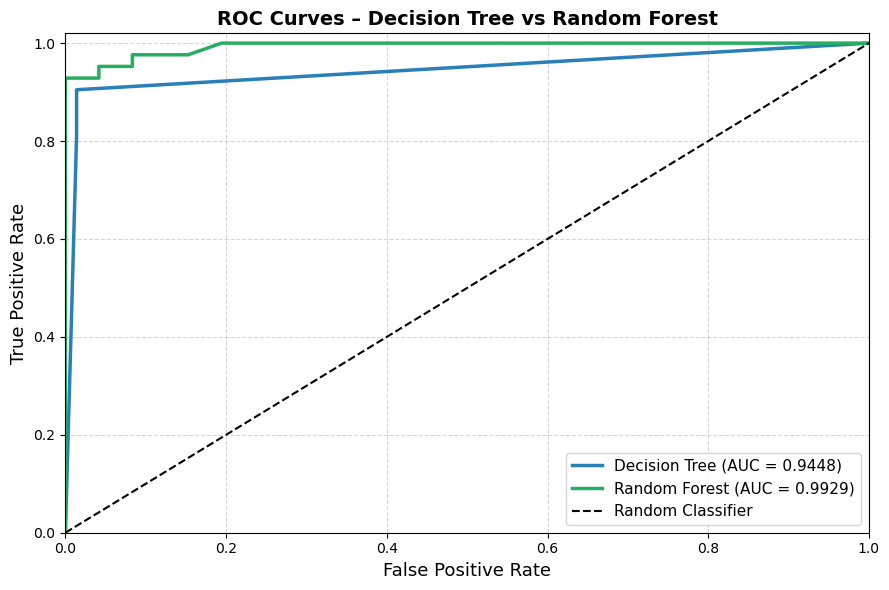

In [102]:
plt.figure(figsize=(9, 6))
colors_roc = ['#2980b9', '#27ae60']

for (name, model), color in zip(trained.items(), colors_roc):
    y_score = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, lw=2.5)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves – Decision Tree vs Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 12: Bar Chart – Metric Comparison

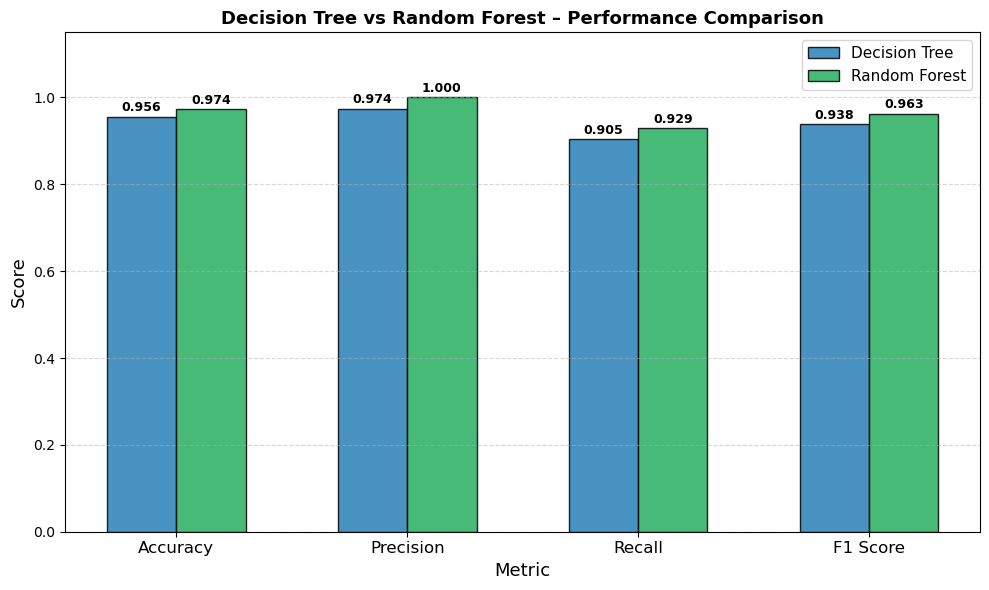

In [103]:
x = np.arange(4)
width = 0.3
bar_colors = ['#2980b9', '#27ae60']

fig, ax = plt.subplots(figsize=(10, 6))
for i, row in df_comp.iterrows():
    vals = [row['Accuracy (%)']/100, row['Precision'], row['Recall'], row['F1 Score']]
    bars = ax.bar(x + i * width, vals, width, label=row['Model'],
                  color=bar_colors[i], edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Decision Tree vs Random Forest – Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score'], fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 13: Feature Importance (Random Forest)

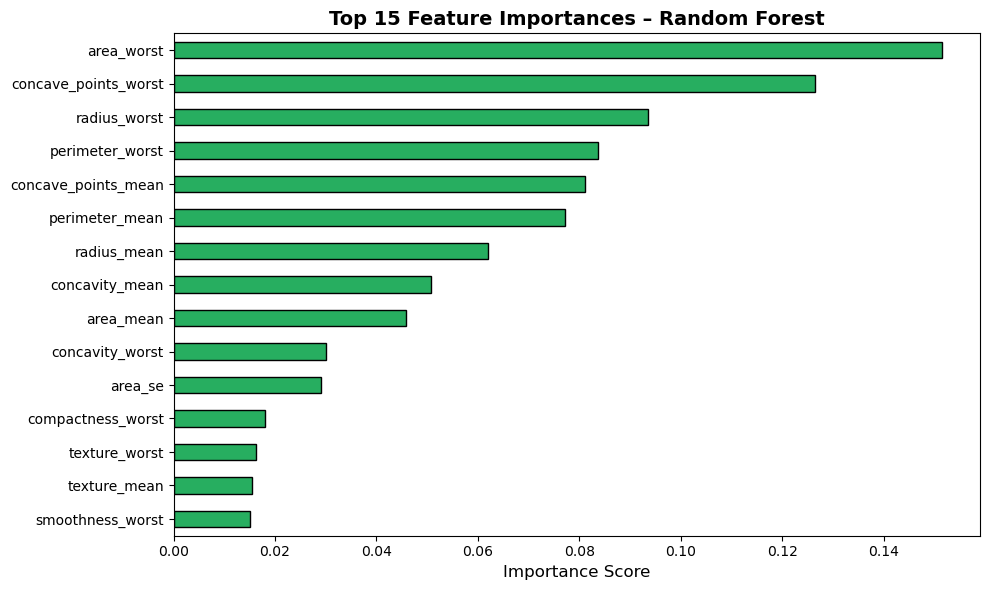

In [104]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).nlargest(15)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='#27ae60', edgecolor='black')
plt.title('Top 15 Feature Importances – Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()